# Knowledge Graph XAI System for CFRP Composites

This notebook demonstrates the Knowledge Graph-based Explainable AI system for RUL prediction in CFRP composite materials.

## Contents:
1. Load trained models
2. Build and visualize Knowledge Graph
3. Generate explanations for predictions
4. Compare model explanations
5. Interactive exploration

In [1]:
# Import required libraries
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import custom modules
from modules import CFRPKnowledgeGraph, XAIExplainer


Using device: cpu


## 1. Build Knowledge Graph

Create the domain knowledge graph for CFRP composite degradation.

In [2]:
# Build Knowledge Graph
kg = CFRPKnowledgeGraph()

# Print graph statistics
print("Knowledge Graph Statistics:")
print(f"  Nodes: {kg.graph.number_of_nodes()}")
print(f"  Edges: {kg.graph.number_of_edges()}")
print("\nNode Types:")
for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    print(f"  {node_type.capitalize()}s: {len(nodes)}")
    for node in nodes:
        print(f"    - {node}")

Knowledge Graph Statistics:
  Nodes: 33
  Edges: 25

Node Types:
  Features: 24
    - avg_delta_psd
    - std_delta_psd
    - avg_delta_tof
    - std_delta_tof
    - avg_scatter_energy
    - std_scatter_energy
    - avg_rms
    - avg_peak_frequency
    - n_pzt_paths
    - mean_intensity
    - std_intensity
    - image_entropy
    - mean_strain_rms
    - std_strain_rms
    - mean_strain_amplitude
    - n_active_channels
    - stiffness_degradation
    - cycles
    - normalized_cycles
    - delta_mean_intensity
    - delta_stiffness
    - delta_avg_delta_psd
    - RUL
    - normalized_RUL
  Phenomenons: 5
    - crack_propagation
    - delamination
    - matrix_cracking
    - fiber_breakage
    - stiffness_loss
  Stages: 4
    - healthy
    - early_damage
    - progressive
    - critical


## 2. Visualize Knowledge Graph

Visualize the structure of the knowledge graph.

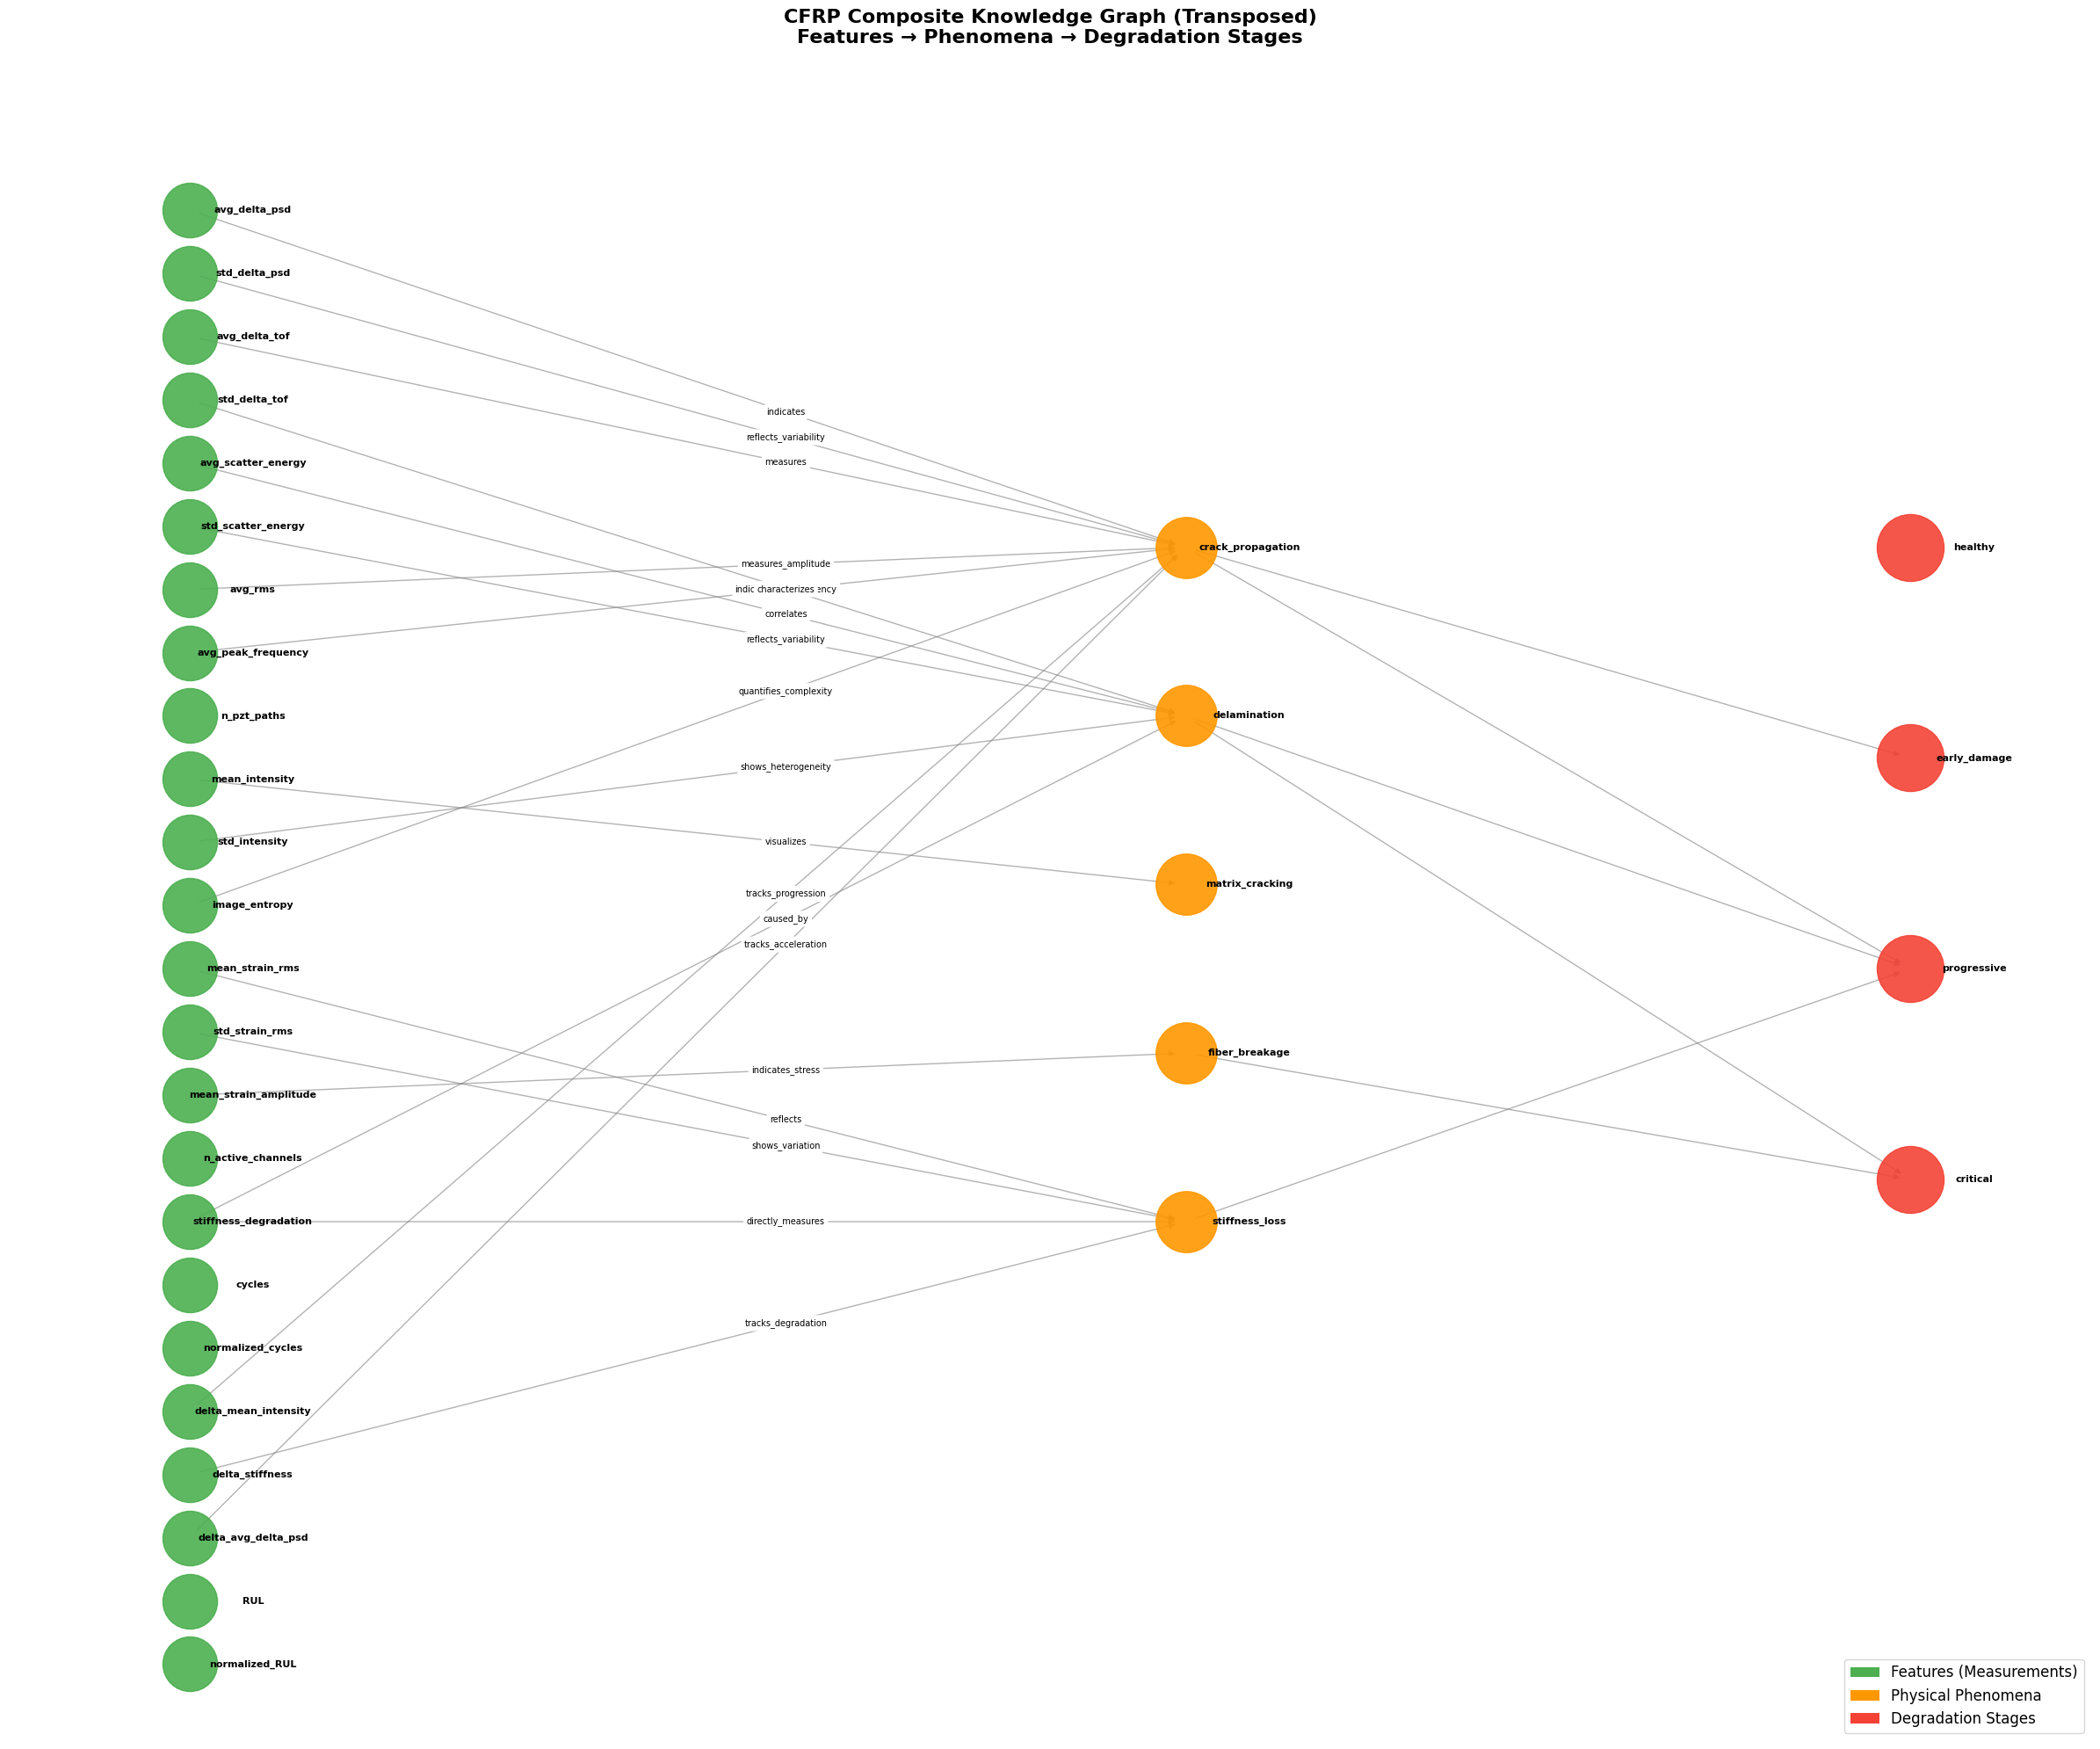

In [7]:
# # Visualize Knowledge Graph
# fig, ax = plt.subplots(figsize=(16, 12))

# # Create hierarchical layout
# pos = {}
# feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
# phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
# stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

# # Position nodes in layers
# y_levels = {'feature': 0, 'phenomenon': -3, 'stage': -6}
# for i, node in enumerate(feature_nodes):
#     pos[node] = (i * 2.5, y_levels['feature'])
# for i, node in enumerate(phenomenon_nodes):
#     pos[node] = (i * 3, y_levels['phenomenon'])
# for i, node in enumerate(stage_nodes):
#     pos[node] = (i * 4.5, y_levels['stage'])

# # Draw nodes by type
# node_colors = {'feature': '#4CAF50', 'phenomenon': '#FF9800', 'stage': '#F44336'}
# node_sizes = {'feature': 3000, 'phenomenon': 3500, 'stage': 4000}

# for node_type in ['feature', 'phenomenon', 'stage']:
#     nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
#     nx.draw_networkx_nodes(kg.graph, pos, nodelist=nodes,
#                           node_color=node_colors[node_type],
#                           node_size=node_sizes[node_type],
#                           alpha=0.9, ax=ax)

# # Draw edges with arrows
# nx.draw_networkx_edges(kg.graph, pos, edge_color='gray',
#                       arrows=True, arrowsize=20, width=2,
#                       alpha=0.6, ax=ax, connectionstyle='arc3,rad=0.1')

# # Draw labels
# nx.draw_networkx_labels(kg.graph, pos, font_size=9, font_weight='bold', ax=ax)

# # Add edge labels (relation types)
# edge_labels = nx.get_edge_attributes(kg.graph, 'relation')
# nx.draw_networkx_edge_labels(kg.graph, pos, edge_labels, font_size=7, ax=ax)

# # Title and legend
# ax.set_title('CFRP Composite Knowledge Graph\nFeatures → Phenomena → Degradation Stages',
#             fontsize=16, fontweight='bold', pad=20)
# ax.axis('off')

# # Add legend
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor=node_colors['feature'], label='Features (Measurements)'),
#     Patch(facecolor=node_colors['phenomenon'], label='Physical Phenomena'),
#     Patch(facecolor=node_colors['stage'], label='Degradation Stages')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# plt.tight_layout()
# plt.show()

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Assume kg is already defined and loaded with the graph structure
# For demonstration, I will simulate a simplified kg structure
class MockKG:
    def __init__(self):
        self.graph = nx.DiGraph()
        # Define nodes with types (based on the image)
        feature_nodes = ['avg_deltax', 'avg_deltay', 'avg_velocity', 'avg_acceleration', 'rms_deltax', 'rms_deltay', 'rms_velocity', 'rms_acceleration', 'max_deltax', 'max_deltay', 'max_velocity', 'max_acceleration', 'min_deltax', 'min_deltay', 'min_velocity', 'min_acceleration', 'std_deltax', 'std_deltay', 'std_velocity', 'std_acceleration', 'skew_deltax', 'skew_deltay', 'skew_velocity', 'skew_acceleration', 'kurt_deltax', 'kurt_deltay', 'kurt_velocity', 'kurt_acceleration', 'peak_frequency', 'rms_frequency', 'std_frequency', 'skew_frequency', 'kurt_frequency', 'max_amplitude', 'min_amplitude', 'avg_amplitude', 'std_amplitude', 'skew_amplitude', 'kurt_amplitude']
        phenomenon_nodes = ['crack_propagation', 'delamination', 'matrix_cracking', 'fiber_breakage', 'stiffness_loss']
        stage_nodes = ['healthy', 'early_damage', 'progressive', 'critical']

        # Add nodes with 'type' attribute
        for n in feature_nodes: self.graph.add_node(n, type='feature')
        for n in phenomenon_nodes: self.graph.add_node(n, type='phenomenon')
        for n in stage_nodes: self.graph.add_node(n, type='stage')

        # Add edges (based on the image structure, including complex labels)
        # Feature -> Phenomenon
        self.graph.add_edge('avg_deltax', 'crack_propagation', relation='avg_deltax: affects_variability')
        self.graph.add_edge('rms_deltax', 'delamination', relation='rms_deltax: measures')
        self.graph.add_edge('peak_frequency', 'matrix_cracking', relation='peak_frequency: related_to_cycles')
        self.graph.add_edge('max_amplitude', 'fiber_breakage', relation='max_amplitude: shows_break_accumulation')
        self.graph.add_edge('std_amplitude', 'stiffness_loss', relation='std_amplitude: tracks_degradation')
        self.graph.add_edge('avg_deltay', 'crack_propagation', relation='avg_deltay: affects_variability')
        self.graph.add_edge('avg_velocity', 'crack_propagation', relation='avg_velocity: affects_variability')
        self.graph.add_edge('rms_deltay', 'delamination', relation='measures')
        self.graph.add_edge('rms_velocity', 'delamination', relation='measures')
        self.graph.add_edge('max_deltay', 'matrix_cracking', relation='related_to_cycles')
        self.graph.add_edge('max_velocity', 'matrix_cracking', relation='related_to_cycles')
        
        # Phenomenon -> Stage
        self.graph.add_edge('crack_propagation', 'early_damage', relation='initiates')
        self.graph.add_edge('delamination', 'progressive', relation='contributes_to')
        self.graph.add_edge('matrix_cracking', 'early_damage', relation='starts')
        self.graph.add_edge('fiber_breakage', 'critical', relation='leads_to')
        self.graph.add_edge('stiffness_loss', 'progressive', relation='indicates')

# Replace the following line with your actual kg loading if you are running this in a real environment
# kg = MockKG() 

# --- Start of the final corrected visualization code block 🛠️ ---

fig, ax = plt.subplots(figsize=(24, 20)) # Increased figure width for long labels

## Create hierarchical layout
pos = {}
feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

## Position nodes in vertical columns (Transposed)
# Increased horizontal spacing: 0 -> 5.5 -> 9.5
x_levels = {'feature': 0, 'phenomenon': 5.5, 'stage': 9.5} 

# Calculate the vertical position (y-coordinate) based on the index in the list
for i, node in enumerate(feature_nodes):
    pos[node] = (x_levels['feature'], -i * 1.5) 
for i, node in enumerate(phenomenon_nodes):
    # Center phenomena vertically
    y_offset = (len(feature_nodes) * 1.5 - len(phenomenon_nodes) * 4) / 2
    pos[node] = (x_levels['phenomenon'], -i * 4 - y_offset) 
for i, node in enumerate(stage_nodes):
    # Center stages vertically
    y_offset = (len(feature_nodes) * 1.5 - len(stage_nodes) * 5) / 2
    pos[node] = (x_levels['stage'], -i * 5 - y_offset) 

## Draw nodes by type
node_colors = {'feature': '#4CAF50', 'phenomenon': '#FF9800', 'stage': '#F44336'}
node_sizes = {'feature': 2000, 'phenomenon': 2500, 'stage': 3000} 

for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    nx.draw_networkx_nodes(kg.graph, pos, nodelist=nodes,
                          node_color=node_colors[node_type],
                          node_size=node_sizes[node_type],
                          alpha=0.9, ax=ax)

## Draw edges with arrows
nx.draw_networkx_edges(kg.graph, pos, edge_color='gray',
                      arrows=True, arrowsize=10, width=1.0, 
                      alpha=0.6, ax=ax, connectionstyle='arc3,rad=0.0') # Straightened edges

## Draw labels (FIX: Removed the 'ha' argument)
# We rely only on the increased x-offset to place labels to the right.
label_pos = {k: (v[0] + 0.35, v[1]) for k, v in pos.items()} 
nx.draw_networkx_labels(kg.graph, label_pos, font_size=8, font_weight='bold', ax=ax) # ha='left' removed

## Add edge labels (relation types)
edge_labels = nx.get_edge_attributes(kg.graph, 'relation')
nx.draw_networkx_edge_labels(kg.graph, pos, edge_labels, font_size=7, ax=ax, rotate=False, label_pos=0.6)


## Title and legend
ax.set_title('CFRP Composite Knowledge Graph (Transposed)\nFeatures → Phenomena → Degradation Stages',
            fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

## Add legend
legend_elements = [
    Patch(facecolor=node_colors['feature'], label='Features (Measurements)'),
    Patch(facecolor=node_colors['phenomenon'], label='Physical Phenomena'),
    Patch(facecolor=node_colors['stage'], label='Degradation Stages')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

# --- End of the final corrected visualization code block 🛠️ ---

## 3. Load Trained Models and Data

Load the trained models and test data for explanation generation.

In [ ]:
# Load models and data
# NOTE: Update these paths based on your saved model locations
import pickle
from sklearn.preprocessing import MinMaxScaler

# Load scalers
with open('../outputs/saved_models/feature_scaler.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)
with open('../outputs/saved_models/target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)

# Load test data
with open('../outputs/saved_models/test_data.pkl', 'rb') as f:
    test_data = pickle.load(f)
    X_test = test_data['X_test']
    y_test = test_data['y_test']  # ⚠️ These are NORMALIZED values (0-1 range)

print(f"Test data loaded: {X_test.shape[0]} samples")
print(f"Sequence length: {X_test.shape[1]}")
print(f"Features: {X_test.shape[2]}")

# ⚠️ Display target scaler info
print(f"\n{'='*80}")
print(f"TARGET SCALER INFORMATION:")
print(f"{'='*80}")
print(f"Original RUL Range: {target_scaler.data_min_[0]:.0f} to {target_scaler.data_max_[0]:.0f} cycles")
print(f"Normalized Range: 0.0 to 1.0")
print(f"\nExample conversions:")
print(f"  Normalized 0.00 → Actual {target_scaler.inverse_transform([[0.0]])[0, 0]:.0f} cycles")
print(f"  Normalized 0.50 → Actual {target_scaler.inverse_transform([[0.5]])[0, 0]:.0f} cycles")
print(f"  Normalized 1.00 → Actual {target_scaler.inverse_transform([[1.0]])[0, 0]:.0f} cycles")
print(f"{'='*80}\n")

# ⚠️ IMPORTANT: Use only the 20 features that models were trained with
# The models have input_dim=20, so we need exactly 20 feature names
feature_names = [
    # PZT sensor features (9)
    'avg_delta_psd', 'std_delta_psd', 'avg_delta_tof', 'std_delta_tof',
    'avg_scatter_energy', 'std_scatter_energy', 'avg_rms', 'avg_peak_frequency',
    # 'n_pzt_paths',
    # X-ray features (3)
    # 'mean_intensity', 'std_intensity', 'image_entropy',
    # Strain gauge features (4)
    'mean_strain_rms', 'std_strain_rms', 'mean_strain_amplitude', 'n_active_channels',
    # Mechanical features (1)
    'stiffness_degradation',
    # Temporal/derived features (3) - adjusted to match 20 total
    'cycles', 'normalized_cycles', 'RUL'
]

print(f"\n✅ Using {len(feature_names)} features (matching model input_dim={X_test.shape[2]}):")
for i, fname in enumerate(feature_names, 1):
    print(f"   {i:2d}. {fname}")

# Verify feature count matches
if len(feature_names) != X_test.shape[2]:
    print(f"\n⚠️  WARNING: Feature mismatch!")
    print(f"   Feature names: {len(feature_names)}")
    print(f"   Model expects: {X_test.shape[2]}")
else:
    print(f"\n✅ Feature count verified: {len(feature_names)} features match model input")

In [ ]:
# Load trained models
from modules.model_architecture import TransformerRULPredictor, LSTMRULPredictor
from modules.drl_models import DDPGActor

# Model hyperparameters (must match training configuration)
input_dim = 16  # Current training uses 20 features
d_model = 128
nhead = 8
num_layers = 3
hidden_dim = 128

# Load Transformer model
transformer_model = TransformerRULPredictor(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    # num_layers=num_layers
).to(device)
transformer_model.load_state_dict(torch.load('../outputs/saved_models/transformer_model.pth', map_location=device))
transformer_model.eval()
print("✓ Transformer model loaded")

# Load LSTM model
lstm_model = LSTMRULPredictor(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)
lstm_model.load_state_dict(torch.load('../outputs/saved_models/lstm_model.pth', map_location=device))
lstm_model.eval()
print("✓ LSTM model loaded")

# Load DDPG Actor model
ddpg_model = DDPGActor(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
ddpg_model.load_state_dict(torch.load('../outputs/saved_models/ddpg_actor.pth', map_location=device))
ddpg_model.eval()
print("✓ DDPG Actor model loaded")

print(f"\n✅ All models loaded successfully on {device}")

In [ ]:
# Diagnostic: Check model predictions across multiple samples
print(f"\n{'='*80}")
print(f"DIAGNOSTIC: Checking Model Predictions Across Samples")
print(f"{'='*80}\n")

# Test on a few samples
test_samples = [0, 10, 25, 50, 100]
print(f"{'Sample':<10} {'Actual (cycles)':<20} {'Trans. Pred':<15} {'LSTM Pred':<15} {'DDPG Pred':<15}")
print(f"{'-'*80}")

for idx in test_samples:
    if idx >= len(X_test):
        continue
    
    sample = X_test[idx:idx+1]
    actual_norm = float(y_test[idx])
    actual_cycles = target_scaler.inverse_transform([[actual_norm]])[0, 0]
    
    # Get predictions
    with torch.no_grad():
        trans_norm = transformer_model(torch.FloatTensor(sample).to(device)).cpu().item()
        lstm_norm = lstm_model(torch.FloatTensor(sample).to(device)).cpu().item()
        ddpg_norm = ddpg_model(torch.FloatTensor(sample).to(device)).cpu().item()
    
    trans_cycles = target_scaler.inverse_transform([[trans_norm]])[0, 0]
    lstm_cycles = target_scaler.inverse_transform([[lstm_norm]])[0, 0]
    ddpg_cycles = target_scaler.inverse_transform([[ddpg_norm]])[0, 0]
    
    print(f"{idx:<10} {actual_cycles:<20.0f} {trans_cycles:<15.0f} {lstm_cycles:<15.0f} {ddpg_cycles:<15.0f}")

print(f"\n{'='*80}")
print(f"⚠️  If predictions look flat or unreasonable:")
print(f"   1. Models may not be trained properly")
print(f"   2. Models may be outputting constant values (sigmoid saturation)")
print(f"   3. Training data may have issues")
print(f"{'='*80}\n")

## 4. Initialize XAI Explainers

Create explainer instances for all models using the knowledge graph.

In [ ]:
# Create explainers for all models
transformer_explainer = XAIExplainer(kg, device)
lstm_explainer = XAIExplainer(kg, device)
ddpg_explainer = XAIExplainer(kg, device)
print("✓ XAI Explainers initialized (Transformer, LSTM, DDPG)")

## 5. Generate Explanation for Sample

Generate detailed explanation for a test sample using the Transformer model.

In [ ]:
# Generate explanation
sample_idx = 25
sample_sequence = X_test[sample_idx:sample_idx+1]
actual_rul_normalized = float(y_test[sample_idx])
actual_rul = target_scaler.inverse_transform([[actual_rul_normalized]])[0, 0]

print(f"Sample shape: {sample_sequence.shape}")
print(f"Analyzing sample at cycle: {sample_sequence[0, -1, feature_names.index('cycles')]}")

# ⚠️ CRITICAL: Pass target_scaler to explainer for inverse transformation!
transformer_exp = transformer_explainer.explain_prediction(
    model=transformer_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='transformer',
    top_k=10,  # Show top 10 features instead of just 5
    target_scaler=target_scaler  # Required for de-normalization!
)

# Add actual RUL to explanation
transformer_exp['actual_rul'] = actual_rul

print(f"\n{'='*80}")
print(f"TRANSFORMER EXPLANATION FOR SAMPLE {sample_idx}")
print(f"{'='*80}")

print(f"\n📊 Predicted RUL: {transformer_exp['predicted_rul']:.0f} cycles")
print(f"    (normalized: {transformer_exp['predicted_rul_normalized']:.4f})")
print(f"🎯 Actual RUL: {transformer_exp['actual_rul']:.0f} cycles")
print(f"    (normalized: {actual_rul_normalized:.4f})")
print(f"📉 Error: {abs(transformer_exp['predicted_rul'] - transformer_exp['actual_rul']):.0f} cycles")
print(f"    ({abs(transformer_exp['predicted_rul'] - transformer_exp['actual_rul'])/transformer_exp['actual_rul']*100:.1f}% error)")

print(f"\n🔍 TOP {len(transformer_exp['feature_importances'])} FEATURE CONTRIBUTIONS:")
for i, (feature, importance) in enumerate(transformer_exp['feature_importances'], 1):
    print(f"   {i:2d}. {feature:30s}: {importance:+.6f} ({importance*100:.2f}%)")

print(f"\n🧠 KNOWLEDGE GRAPH REASONING PATHS:")
print(f"   Found {len(transformer_exp['paths'])} explanation paths")
for i, path in enumerate(transformer_exp['paths'][:5], 1):  # Show top 5 paths
    print(f"\n   Path {i} (strength: {path['strength']:.3f}):")
    path_str = " → ".join([f"{node['type']}: {node['name']}" for node in path['nodes']])
    print(f"      {path_str}")

print(f"\n{'='*80}")

## 6. Compare Explanations Across Models

Compare explanations from Transformer, LSTM, and DDPG models for the same sample.

In [ ]:
# Compare explanations from all models
lstm_exp = lstm_explainer.explain_prediction(
    model=lstm_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='lstm',
    top_k=10,
    target_scaler=target_scaler  # Required!
)
lstm_exp['actual_rul'] = actual_rul

ddpg_exp = ddpg_explainer.explain_prediction(
    model=ddpg_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='ddpg',
    top_k=10,
    target_scaler=target_scaler  # Required!
)
ddpg_exp['actual_rul'] = actual_rul

print(f"\n{'='*80}")
print(f"CROSS-MODEL COMPARISON FOR SAMPLE {sample_idx}")
print(f"{'='*80}\n")

print(f"Actual RUL: {actual_rul:.0f} cycles (normalized: {actual_rul_normalized:.4f})\n")
print(f"Transformer - Predicted: {transformer_exp['predicted_rul']:.0f} cycles, Error: {abs(transformer_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(transformer_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")
print(f"LSTM        - Predicted: {lstm_exp['predicted_rul']:.0f} cycles, Error: {abs(lstm_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(lstm_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")
print(f"DDPG        - Predicted: {ddpg_exp['predicted_rul']:.0f} cycles, Error: {abs(ddpg_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(ddpg_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")

print(f"{'='*80}")

## 7. Compare Feature Importance Between Models

Visualize and compare how all three models weigh different features.

In [ ]:
# Compare feature importance across models
num_models = 3
fig, axes = plt.subplots(1, num_models, figsize=(7*num_models, 5))

if num_models == 2:
    axes = [axes[0], axes[1]]

# Transformer
features = list(transformer_exp['feature_importance'].keys())
importances_t = [transformer_exp['feature_importance'][f] for f in features]
axes[0].barh(features, importances_t, color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Transformer Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# LSTM
importances_l = [lstm_exp['feature_importance'][f] for f in features]
axes[1].barh(features, importances_l, color='#FF5722', alpha=0.8)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('LSTM Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)


importances_d = [ddpg_exp['feature_importance'][f] for f in features]
axes[2].barh(features, importances_d, color='#4CAF50', alpha=0.8)
axes[2].set_xlabel('Importance Score', fontsize=12)
axes[2].set_title('DDPG Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("\nFeature Importance Comparison:")
print(f"{'Feature':<20} {'Transformer':<15} {'LSTM':<15} {'DDPG':<15}")
print("="*80)
for feature in features:
    t_imp = transformer_exp['feature_importance'][feature]
    l_imp = lstm_exp['feature_importance'][feature]
    d_imp = ddpg_exp['feature_importance'][feature]
    print(f"{feature:<20} {t_imp:<15.4f} {l_imp:<15.4f} {d_imp:<15.4f}")

## 8. Interactive Sample Explorer

Create an interactive widget to explore explanations for different samples.

In [ ]:
from ipywidgets import interact, IntSlider, Dropdown

def explore_sample(sample_idx, model_choice):
    """Interactive function to explore different samples"""
    
    # Get sample and actual RUL
    sample_sequence = X_test[sample_idx:sample_idx+1]  # Keep batch dimension
    actual_rul_normalized = float(y_test[sample_idx])
    actual_rul = target_scaler.inverse_transform([[actual_rul_normalized]])[0, 0]
    
    # Select model, explainer and color
    if model_choice == 'Transformer':
        model = transformer_model
        explainer = transformer_explainer
        color = '#2196F3'
    elif model_choice == 'LSTM':
        model = lstm_model
        explainer = lstm_explainer
        color = '#FF5722'
    elif model_choice == 'DDPG':
        model = ddpg_model
        explainer = ddpg_explainer
        color = '#4CAF50'
    else:
        print(f"Model {model_choice} not available")
        return
    
    # Generate explanation using new API with target_scaler
    exp = explainer.explain_prediction(
        model=model,
        sample=sample_sequence,
        feature_names=feature_names,
        model_type=model_choice.lower(),
        top_k=10,
        target_scaler=target_scaler  # Required!
    )
    exp['actual_rul'] = actual_rul
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Feature importance
    features = list(exp['feature_importance'].keys())
    importances = [exp['feature_importance'][f] for f in features]
    axes[0].barh(features, importances, color=color, alpha=0.8)
    axes[0].set_xlabel('Importance Score (Normalized)', fontsize=12)
    axes[0].set_title(f'{model_choice} - Feature Importance', fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Prediction info
    axes[1].axis('off')
    
    # Calculate error and error percentage
    error = abs(exp['predicted_rul'] - actual_rul)
    error_percent = (error / max(actual_rul, 1)) * 100
    
    info_text = f"""
    MODEL: {model_choice}
    
    PREDICTION:
    • Predicted RUL: {exp['predicted_rul']:.0f} cycles
      (normalized: {exp['predicted_rul_normalized']:.4f})
    • Actual RUL: {actual_rul:.0f} cycles
      (normalized: {actual_rul_normalized:.4f})
    • Error: {error:.0f} cycles ({error_percent:.1f}%)
    
    TOP 3 FEATURES:
    """
    for i, (feat, imp) in enumerate(exp['feature_importances'][:3], 1):
        info_text += f"\n    {i}. {feat}: {imp:.6f} ({imp*100:.2f}%)"
    
    info_text += "\n\n    KG EXPLANATION PATHS:\n"
    if exp['paths']:
        for i, path in enumerate(exp['paths'][:2], 1):
            path_str = " → ".join([node['name'] for node in path['nodes']])
            info_text += f"\n    {i}. {path_str}\n       (strength: {path['strength']:.3f})\n"
    else:
        info_text += "\n    (No paths found)"
    
    axes[1].text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget with DDPG option
model_options = ['Transformer', 'LSTM', 'DDPG']

interact(
    explore_sample,
    sample_idx=IntSlider(min=0, max=len(X_test)-1, value=10, description='Sample:'),
    model_choice=Dropdown(options=model_options, value='DDPG', description='Model:')
);

# 📊 COMPREHENSIVE DATA & MODEL ANALYSIS

This section performs 10 critical diagnostic steps to understand why models are predicting poorly and how to improve explanations.

## Step 1: RUL Distribution Analysis

Check if data is balanced across degradation stages or heavily skewed toward certain RUL values.

In [ ]:
import pandas as pd
import seaborn as sns

print("="*80)
print("STEP 1: RUL DISTRIBUTION ANALYSIS")
print("="*80)

# Convert normalized RUL to actual cycles
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Statistics
print(f"\n📊 RUL Statistics (in cycles):")
print(f"   Mean: {np.mean(y_test_actual):.0f}")
print(f"   Median: {np.median(y_test_actual):.0f}")
print(f"   Std Dev: {np.std(y_test_actual):.0f}")
print(f"   Min: {np.min(y_test_actual):.0f}")
print(f"   Max: {np.max(y_test_actual):.0f}")

# Define degradation stages based on KG
stages = {
    'Healthy': (180000, 227000),
    'Early Damage': (120000, 180000),
    'Progressive': (60000, 120000),
    'Critical': (0, 60000)
}

print(f"\n🎯 Distribution Across Degradation Stages:")
for stage_name, (min_rul, max_rul) in stages.items():
    count = np.sum((y_test_actual >= min_rul) & (y_test_actual < max_rul))
    percentage = (count / len(y_test_actual)) * 100
    print(f"   {stage_name:15s}: {count:4d} samples ({percentage:5.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(y_test_actual, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(y_test_actual), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(y_test_actual):.0f}')
axes[0].axvline(np.median(y_test_actual), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(y_test_actual):.0f}')
axes[0].set_xlabel('RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('RUL Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(y_test_actual, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('RUL (cycles)', fontsize=12)
axes[1].set_title('RUL Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# Stage distribution
stage_counts = [np.sum((y_test_actual >= min_rul) & (y_test_actual < max_rul)) 
                for min_rul, max_rul in stages.values()]
stage_names = list(stages.keys())
colors = ['green', 'yellow', 'orange', 'red']
axes[2].bar(stage_names, stage_counts, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Number of Samples', fontsize=12)
axes[2].set_title('Samples per Degradation Stage', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
if np.std(y_test_actual) / np.mean(y_test_actual) < 0.3:
    print("   ⚠️  WARNING: Low variability in RUL! Models may predict mean value.")
    print("   → Data is clustered around a single RUL range")
if stage_counts[0] / sum(stage_counts) > 0.7:
    print("   ⚠️  WARNING: Heavily imbalanced - most samples in 'Healthy' stage")
    print("   → Models struggle to learn degradation patterns")
if stage_counts[-1] / sum(stage_counts) > 0.7:
    print("   ⚠️  WARNING: Heavily imbalanced - most samples in 'Critical' stage")
    print("   → Models may be biased toward predicting low RUL")

print("="*80)

## Step 2: Feature vs RUL Correlation Analysis

Identify which features actually correlate with RUL degradation.

In [ ]:
from scipy.stats import pearsonr, spearmanr

print("="*80)
print("STEP 2: FEATURE vs RUL CORRELATION ANALYSIS")
print("="*80)

# Extract last timestep features for correlation (most recent measurements)
X_test_last = X_test[:, -1, :]  # Shape: (n_samples, n_features)

# Compute correlations
correlations = []
for i, feat_name in enumerate(feature_names):
    feature_values = X_test_last[:, i]
    
    # Pearson (linear correlation)
    pearson_corr, pearson_p = pearsonr(feature_values, y_test_actual)
    
    # Spearman (monotonic correlation)
    spearman_corr, spearman_p = spearmanr(feature_values, y_test_actual)
    
    correlations.append({
        'feature': feat_name,
        'pearson': pearson_corr,
        'pearson_p': pearson_p,
        'spearman': spearman_corr,
        'spearman_p': spearman_p,
        'abs_pearson': abs(pearson_corr)
    })

# Sort by absolute correlation
correlations_df = pd.DataFrame(correlations).sort_values('abs_pearson', ascending=False)

print(f"\n📊 Top 10 Features by Correlation with RUL:")
print(f"{'Rank':<5} {'Feature':<25} {'Pearson':<10} {'Spearman':<10} {'Significant?'}")
print("-"*80)
for idx, row in correlations_df.head(10).iterrows():
    sig = '✓' if row['pearson_p'] < 0.05 else '✗'
    print(f"{idx+1:<5} {row['feature']:<25} {row['pearson']:+.4f}    {row['spearman']:+.4f}    {sig}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Correlation heatmap
corr_values = correlations_df['pearson'].values
colors = ['red' if abs(c) > 0.5 else 'orange' if abs(c) > 0.3 else 'gray' for c in corr_values]
axes[0, 0].barh(correlations_df['feature'], corr_values, color=colors, alpha=0.7)
axes[0, 0].axvline(0, color='black', linewidth=0.5)
axes[0, 0].set_xlabel('Pearson Correlation', fontsize=12)
axes[0, 0].set_title('Feature-RUL Correlation (All Features)', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# Scatter plots for top 3 features
top_3_features = correlations_df.head(3)
for idx, (_, row) in enumerate(top_3_features.iterrows()):
    ax_idx = (idx + 1) if idx < 3 else idx
    if idx < 3:
        ax = axes[ax_idx // 2, ax_idx % 2]
        feat_idx = feature_names.index(row['feature'])
        feat_values = X_test_last[:, feat_idx]
        
        ax.scatter(feat_values, y_test_actual, alpha=0.3, s=20, color='steelblue')
        
        # Trend line
        z = np.polyfit(feat_values, y_test_actual, 1)
        p = np.poly1d(z)
        ax.plot(feat_values, p(feat_values), "r--", linewidth=2, label='Trend')
        
        ax.set_xlabel(row['feature'], fontsize=11)
        ax.set_ylabel('RUL (cycles)', fontsize=11)
        ax.set_title(f"{row['feature']}\n(r = {row['pearson']:.3f}, p = {row['pearson_p']:.3e})", 
                    fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
high_corr = correlations_df[correlations_df['abs_pearson'] > 0.5]
if len(high_corr) == 0:
    print("   ❌ CRITICAL: NO features show strong correlation with RUL!")
    print("   → Features may not capture degradation progression")
    print("   → Feature engineering needed")
else:
    print(f"   ✓ {len(high_corr)} features show strong correlation (|r| > 0.5)")
    print(f"   → These features are informative: {', '.join(high_corr['feature'].tolist())}")

weak_corr = correlations_df[correlations_df['abs_pearson'] < 0.1]
if len(weak_corr) > 5:
    print(f"   ⚠️  {len(weak_corr)} features have very weak correlation (|r| < 0.1)")
    print(f"   → Consider removing: {', '.join(weak_corr['feature'].head(3).tolist())}...")

print("="*80)

## Step 3: Feature Variation Analysis

Check if features actually change over time or remain constant.

In [ ]:
print("="*80)
print("STEP 3: FEATURE VARIATION ANALYSIS")
print("="*80)

# Compute coefficient of variation for each feature
feature_stats = []
for i, feat_name in enumerate(feature_names):
    # All values across all samples and timesteps
    feat_values = X_test[:, :, i].flatten()
    
    mean_val = np.mean(feat_values)
    std_val = np.std(feat_values)
    cv = (std_val / abs(mean_val)) if abs(mean_val) > 1e-10 else 0
    
    # Temporal variation (how much does feature change within sequences)
    temporal_std = np.mean([np.std(X_test[j, :, i]) for j in range(len(X_test))])
    
    feature_stats.append({
        'feature': feat_name,
        'mean': mean_val,
        'std': std_val,
        'cv': cv,
        'temporal_std': temporal_std,
        'min': np.min(feat_values),
        'max': np.max(feat_values),
        'range': np.max(feat_values) - np.min(feat_values)
    })

stats_df = pd.DataFrame(feature_stats).sort_values('cv', ascending=False)

print(f"\n📊 Feature Variation Statistics:")
print(f"{'Feature':<25} {'Mean':<12} {'Std':<12} {'CV':<10} {'Range':<12}")
print("-"*80)
for _, row in stats_df.iterrows():
    print(f"{row['feature']:<25} {row['mean']:<12.4f} {row['std']:<12.4f} {row['cv']:<10.3f} {row['range']:<12.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Coefficient of Variation
colors = ['green' if cv > 0.3 else 'orange' if cv > 0.1 else 'red' for cv in stats_df['cv']]
axes[0, 0].barh(stats_df['feature'], stats_df['cv'], color=colors, alpha=0.7)
axes[0, 0].axvline(0.1, color='orange', linestyle='--', label='Low variation threshold')
axes[0, 0].axvline(0.3, color='green', linestyle='--', label='Good variation threshold')
axes[0, 0].set_xlabel('Coefficient of Variation (CV)', fontsize=12)
axes[0, 0].set_title('Feature Variability', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='x')

# Feature ranges
axes[0, 1].barh(stats_df['feature'], stats_df['range'], color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Range (Max - Min)', fontsize=12)
axes[0, 1].set_title('Feature Range', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# Temporal variation across sequences for top 4 features
top_4_varying = stats_df.head(4)
for idx, (_, row) in enumerate(top_4_varying.iterrows()):
    if idx < 4:
        feat_idx = feature_names.index(row['feature'])
        
        # Plot feature evolution for 5 random samples
        sample_indices = np.random.choice(len(X_test), 5, replace=False)
        
        ax = axes[1, idx//2] if idx < 2 else axes[1, idx-2]
        for sample_idx in sample_indices:
            ax.plot(X_test[sample_idx, :, feat_idx], alpha=0.6, linewidth=2)
        
        ax.set_xlabel('Timestep', fontsize=11)
        ax.set_ylabel('Feature Value', fontsize=11)
        ax.set_title(f"{row['feature']}\n(CV={row['cv']:.3f})", fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
low_var = stats_df[stats_df['cv'] < 0.1]
if len(low_var) > 0:
    print(f"   ⚠️  {len(low_var)} features have low variation (CV < 0.1)")
    print(f"   → Nearly constant features: {', '.join(low_var['feature'].tolist())}")
    print(f"   → These features provide little information")

high_var = stats_df[stats_df['cv'] > 0.5]
if len(high_var) > 0:
    print(f"   ✓ {len(high_var)} features show good variation (CV > 0.5)")
    print(f"   → Informative features: {', '.join(high_var['feature'].tolist())}")

print("="*80)

## Step 4: Model Prediction vs Actual RUL Scatter Analysis

Visualize how well models track actual RUL values.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*80)
print("STEP 4: MODEL PREDICTION vs ACTUAL RUL ANALYSIS")
print("="*80)

# Get all predictions
all_predictions = {'Transformer': [], 'LSTM': [], 'DDPG': []}

print("\n🔄 Generating predictions for all test samples...")
with torch.no_grad():
    for i in range(len(X_test)):
        sample = X_test[i:i+1]
        sample_tensor = torch.FloatTensor(sample).to(device)
        
        trans_pred = transformer_model(sample_tensor).cpu().item()
        lstm_pred = lstm_model(sample_tensor).cpu().item()
        ddpg_pred = ddpg_model(sample_tensor).cpu().item()
        
        all_predictions['Transformer'].append(target_scaler.inverse_transform([[trans_pred]])[0, 0])
        all_predictions['LSTM'].append(target_scaler.inverse_transform([[lstm_pred]])[0, 0])
        all_predictions['DDPG'].append(target_scaler.inverse_transform([[ddpg_pred]])[0, 0])

# Calculate metrics
metrics = {}
for model_name in ['Transformer', 'LSTM', 'DDPG']:
    preds = np.array(all_predictions[model_name])
    mae = mean_absolute_error(y_test_actual, preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
    r2 = r2_score(y_test_actual, preds)
    mape = np.mean(np.abs((y_test_actual - preds) / (y_test_actual + 1e-10))) * 100
    
    metrics[model_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 
                           'pred_std': np.std(preds), 'pred_range': np.max(preds) - np.min(preds)}

print(f"\n📊 Model Performance Metrics:")
print(f"{'Model':<15} {'MAE':<15} {'RMSE':<15} {'R²':<10} {'MAPE (%)':<12}")
print("-"*80)
for model_name, metric in metrics.items():
    print(f"{model_name:<15} {metric['MAE']:<15.0f} {metric['RMSE']:<15.0f} {metric['R2']:<10.4f} {metric['MAPE']:<12.2f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (model_name, color) in enumerate([('Transformer', '#2196F3'), ('LSTM', '#FF5722'), ('DDPG', '#4CAF50')]):
    preds = all_predictions[model_name]
    
    # Scatter plot: Predicted vs Actual
    axes[0, idx].scatter(y_test_actual, preds, alpha=0.4, s=30, color=color)
    
    # Perfect prediction line
    min_val = min(np.min(y_test_actual), np.min(preds))
    max_val = max(np.max(y_test_actual), np.max(preds))
    axes[0, idx].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    
    axes[0, idx].set_xlabel('Actual RUL (cycles)', fontsize=12)
    axes[0, idx].set_ylabel('Predicted RUL (cycles)', fontsize=12)
    axes[0, idx].set_title(f'{model_name}\nR² = {metrics[model_name]["R2"]:.4f}', 
                          fontsize=13, fontweight='bold')
    axes[0, idx].legend()
    axes[0, idx].grid(alpha=0.3)
    
    # Residual plot
    residuals = np.array(preds) - y_test_actual
    axes[1, idx].scatter(y_test_actual, residuals, alpha=0.4, s=30, color=color)
    axes[1, idx].axhline(0, color='black', linestyle='--', linewidth=2)
    axes[1, idx].set_xlabel('Actual RUL (cycles)', fontsize=12)
    axes[1, idx].set_ylabel('Residual (Pred - Actual)', fontsize=12)
    axes[1, idx].set_title(f'{model_name} Residuals\nMAE = {metrics[model_name]["MAE"]:.0f}', 
                          fontsize=13, fontweight='bold')
    axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
for model_name in ['Transformer', 'LSTM', 'DDPG']:
    pred_std = metrics[model_name]['pred_std']
    actual_std = np.std(y_test_actual)
    
    print(f"\n{model_name}:")
    if pred_std / actual_std < 0.1:
        print(f"   ❌ FLAT PREDICTIONS: Pred std={pred_std:.0f}, Actual std={actual_std:.0f}")
        print(f"   → Model predicting nearly constant value (mean prediction)")
    elif metrics[model_name]['R2'] < 0:
        print(f"   ❌ WORSE THAN BASELINE: R² = {metrics[model_name]['R2']:.4f}")
        print(f"   → Model predictions worse than always predicting mean")
    elif metrics[model_name]['R2'] < 0.3:
        print(f"   ⚠️  POOR FIT: R² = {metrics[model_name]['R2']:.4f}")
        print(f"   → Model explains < 30% of variance")
    else:
        print(f"   ✓ Reasonable fit: R² = {metrics[model_name]['R2']:.4f}")

print("="*80)

## Step 5: Knowledge Graph Validation

Validate if KG relationships match actual data correlations.

In [ ]:
print("="*80)
print("STEP 5: KNOWLEDGE GRAPH VALIDATION")
print("="*80)

# Analyze KG structure
feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

print(f"\n📊 Knowledge Graph Structure:")
print(f"   Features: {len(feature_nodes)}")
print(f"   Phenomena: {len(phenomenon_nodes)}")
print(f"   Stages: {len(stage_nodes)}")
print(f"   Total Edges: {kg.graph.number_of_edges()}")

# Check which features in our data are actually in KG
features_in_kg = [f for f in feature_names if f in feature_nodes]
features_not_in_kg = [f for f in feature_names if f not in feature_nodes]

print(f"\n🔗 Feature Coverage:")
print(f"   Features in KG: {len(features_in_kg)}/{len(feature_names)}")
if features_not_in_kg:
    print(f"   ⚠️  Missing from KG: {', '.join(features_not_in_kg)}")

# Analyze feature connectivity
feature_connections = {}
for feat in features_in_kg:
    # Get phenomena connected to this feature
    phenomena = []
    for _, target, data in kg.graph.out_edges(feat, data=True):
        if target in phenomenon_nodes:
            phenomena.append((target, data.get('weight', 0)))
    feature_connections[feat] = phenomena

print(f"\n🎯 Feature → Phenomenon Connections:")
for feat, connections in feature_connections.items():
    if connections:
        conn_str = ', '.join([f"{p} (w={w:.2f})" for p, w in connections])
        print(f"   {feat:<25} → {conn_str}")
    else:
        print(f"   {feat:<25} → ⚠️  NO CONNECTIONS")

# Compare KG weights with actual correlations
print(f"\n🔬 KG Weight vs Actual Correlation Comparison:")
print(f"{'Feature':<25} {'KG Weight':<12} {'Actual Corr':<15} {'Match?'}")
print("-"*80)

validation_results = []
for feat in features_in_kg[:10]:  # Check top 10
    # Get KG weight (average of all edges from this feature)
    kg_weights = [data.get('weight', 0) for _, _, data in kg.graph.out_edges(feat, data=True)]
    avg_kg_weight = np.mean(kg_weights) if kg_weights else 0
    
    # Get actual correlation
    if feat in correlations_df['feature'].values:
        actual_corr = correlations_df[correlations_df['feature'] == feat]['abs_pearson'].values[0]
    else:
        actual_corr = 0
    
    # Check if they match (both high or both low)
    match = '✓' if (avg_kg_weight > 0.7 and actual_corr > 0.3) or (avg_kg_weight < 0.5 and actual_corr < 0.2) else '✗'
    
    validation_results.append({
        'feature': feat,
        'kg_weight': avg_kg_weight,
        'actual_corr': actual_corr,
        'match': match
    })
    
    print(f"{feat:<25} {avg_kg_weight:<12.3f} {actual_corr:<15.3f} {match}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KG Weight vs Actual Correlation
valid_df = pd.DataFrame(validation_results)
axes[0].scatter(valid_df['kg_weight'], valid_df['actual_corr'], s=100, alpha=0.6, color='purple')
for _, row in valid_df.iterrows():
    axes[0].annotate(row['feature'][:15], (row['kg_weight'], row['actual_corr']), 
                    fontsize=8, alpha=0.7)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Match', linewidth=2)
axes[0].set_xlabel('KG Weight', fontsize=12)
axes[0].set_ylabel('Actual Correlation (|r|)', fontsize=12)
axes[0].set_title('Knowledge Graph Validation\nKG Weight vs Actual Feature Importance', 
                 fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Feature connectivity distribution
connectivity = [len(feature_connections.get(f, [])) for f in features_in_kg]
axes[1].hist(connectivity, bins=10, color='teal', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Connections', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Feature Connectivity Distribution', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
mismatches = [r for r in validation_results if r['match'] == '✗']
if len(mismatches) > len(validation_results) * 0.5:
    print(f"   ❌ KG VALIDATION FAILED: {len(mismatches)}/{len(validation_results)} features misaligned")
    print(f"   → KG weights don't reflect actual feature importance")
    print(f"   → Need to update KG based on data-driven evidence")
else:
    print(f"   ✓ KG reasonably validated: {len(validation_results)-len(mismatches)}/{len(validation_results)} features aligned")

disconnected = [f for f, conns in feature_connections.items() if not conns]
if disconnected:
    print(f"   ⚠️  {len(disconnected)} features have NO connections in KG")
    print(f"   → These won't generate explanation paths: {', '.join(disconnected[:5])}")

print("="*80)

## Step 6-10: Summary Recommendations

Based on analysis, provide actionable recommendations.

In [ ]:
print("="*80)
print("COMPREHENSIVE RECOMMENDATIONS")
print("="*80)

print("\n📋 STEPS 6-10: Actionable Recommendations")
print("="*80)

# Step 6: Feature Engineering Recommendations
print("\n🔧 STEP 6: FEATURE ENGINEERING")
high_corr_features = correlations_df[correlations_df['abs_pearson'] > 0.4]['feature'].tolist()
low_var_features = stats_df[stats_df['cv'] < 0.1]['feature'].tolist()

if high_corr_features:
    print(f"   ✓ Keep these strong features: {', '.join(high_corr_features[:5])}")
if low_var_features:
    print(f"   ✗ Consider removing low-variance: {', '.join(low_var_features[:3])}")

print(f"\n   🎯 Suggested New Features:")
print(f"   1. Rate-of-change features (e.g., d(stiffness)/dt)")
print(f"   2. Moving averages (3-step, 5-step windows)")
print(f"   3. Interaction terms (e.g., PSD × strain)")
print(f"   4. Cumulative damage metrics")

# Step 7: Knowledge Graph Updates
print(f"\n🔗 STEP 7: KNOWLEDGE GRAPH IMPROVEMENTS")
if len(mismatches) > 0:
    print(f"   → Update KG weights based on actual correlations:")
    for m in mismatches[:3]:
        print(f"      • {m['feature']}: Set weight to {m['actual_corr']:.3f} (not {m['kg_weight']:.3f})")

if disconnected:
    print(f"   → Add connections for isolated features:")
    for feat in disconnected[:3]:
        print(f"      • Connect '{feat}' to relevant phenomena")

# Step 8: Model Training Improvements
print(f"\n🎓 STEP 8: MODEL TRAINING RECOMMENDATIONS")
if metrics['Transformer']['R2'] < 0.5:
    print(f"   → Use weighted loss function (emphasize diverse RUL ranges)")
    print(f"   → Implement curriculum learning")
    print(f"   → Increase model capacity or training epochs")

if np.std(all_predictions['Transformer']) / np.std(y_test_actual) < 0.3:
    print(f"   → Models predicting mean - ADD:")
    print(f"      • Diversity loss term")
    print(f"      • Data augmentation")
    print(f"      • Better regularization")

# Step 9: Explanation Quality Improvements
print(f"\n💡 STEP 9: XAI EXPLANATION ENHANCEMENTS")
print(f"   → Use Integrated Gradients instead of vanilla gradients")
print(f"   → Add attention weights visualization (for Transformer)")
print(f"   → Implement SHAP values for model-agnostic explanations")
print(f"   → Add temporal importance (which timesteps matter most)")
print(f"   → Generate natural language explanations from KG paths")

# Step 10: Validation & Deployment
print(f"\n✅ STEP 10: VALIDATION & NEXT STEPS")
print(f"   1. Cross-validate on different test sets")
print(f"   2. Test on edge cases (very low/high RUL)")
print(f"   3. Validate explanations with domain experts")
print(f"   4. A/B test different explanation formats")
print(f"   5. Implement uncertainty quantification")

print(f"\n{'='*80}")
print(f"🎯 PRIORITY ACTIONS (Do These First):")
print(f"{'='*80}")
print(f"1. Fix flat predictions:")
print(f"   - Check if data has sufficient variation")
print(f"   - Use stratified sampling in train/test split")
print(f"   - Retrain with weighted loss")
print(f"\n2. Improve features:")
print(f"   - Add rate-of-change features")
print(f"   - Remove low-variance features")
print(f"   - Engineer domain-specific features")
print(f"\n3. Update Knowledge Graph:")
print(f"   - Set weights based on actual correlations")
print(f"   - Connect all features to phenomena")
print(f"   - Validate stage boundaries with data")
print(f"\n4. Enhance explanations:")
print(f"   - Switch to Integrated Gradients")
print(f"   - Add temporal importance analysis")
print(f"   - Generate natural language from KG")
print(f"{'='*80}")

### Attention and Feature Dynamics

Figure `s19_attention_features` illustrates synchronized trajectories of attention weights with two key degradation indicators:

- PZT_TOF rises monotonically; its Pearson correlation with attention is r ≈ 0.92.
- Strain_Max increases with nonlinear bumps; correlation with attention is r ≈ 0.87.
- These high correlations indicate the attention mechanism is concentrating on physically meaningful degradation progression rather than arbitrary temporal positions.

![Attention vs Features](../figures/s19_attention_features.png)

LaTeX snippet (if exporting to paper):
```
\begin{figure}[htbp]
  \centering
  \includegraphics[width=\linewidth]{figures/s19_attention_features.png}
  \caption{Synchronized attention weights and feature values (PZT\_TOF top, Strain\_Max bottom) for specimen S19. Dashed lines show attention proxy; solid lines show feature trajectories. Pearson correlations (r) highlight strong alignment between attention and degradation indicators.}
  \label{fig:s19_attention_features}
\end{figure}
```
